In [10]:
from src.visualize_poly_mse import plot_layer_fit
plot_layer_fit(block_idx=22, layer_type="txt_mlp_fc2")

Saved poly_fit_mm22_txt_mlp_fc2.png


In [20]:
%matplotlib inline
import json
import re
import matplotlib.pyplot as plt
import numpy as np


def plot_mse_by_block(config_path="gptq_output/config.json", mse_key="weight_mse",
                      layer_types=None, title=None):
    """Plot per-block MSE as a line plot with one line per layer type.

    Args:
        config_path: Path to GPTQ config.json.
        mse_key: "weight_mse" or "activation_mse".
        layer_types: List of layer types to plot, e.g. ["img_attn_q_proj", "txt_mlp_fc1"].
                     If None, plots all layer types.
        title: Plot title override.
    """
    with open(config_path) as f:
        config = json.load(f)

    mse_data = config[mse_key]

    # Parse keys like "mm0_img_attn_q_proj" -> (block_idx=0, layer_type="img_attn_q_proj")
    pattern = re.compile(r"^mm(\d+)_(.+)$")
    # Collect: {layer_type: {block_idx: mse}}
    by_type = {}
    for key, mse in mse_data.items():
        m = pattern.match(key)
        if not m:
            continue
        block_idx = int(m.group(1))
        layer_type = m.group(2)
        if layer_types is not None and layer_type not in layer_types:
            continue
        by_type.setdefault(layer_type, {})[block_idx] = mse

    fig, ax = plt.subplots(figsize=(14, 6))

    for layer_type in sorted(by_type.keys()):
        block_mses = by_type[layer_type]
        blocks = sorted(block_mses.keys())
        values = [block_mses[b] for b in blocks]
        ax.plot([b + 1 for b in blocks], values, marker="o", markersize=3,
                label=layer_type, linewidth=1.5)

    ax.set_xlabel("Block")
    ax.set_ylabel("MSE")
    ax.set_xticks(range(1, 25))
    ax.set_title(title or f"{mse_key} by block and layer type")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    # return fig

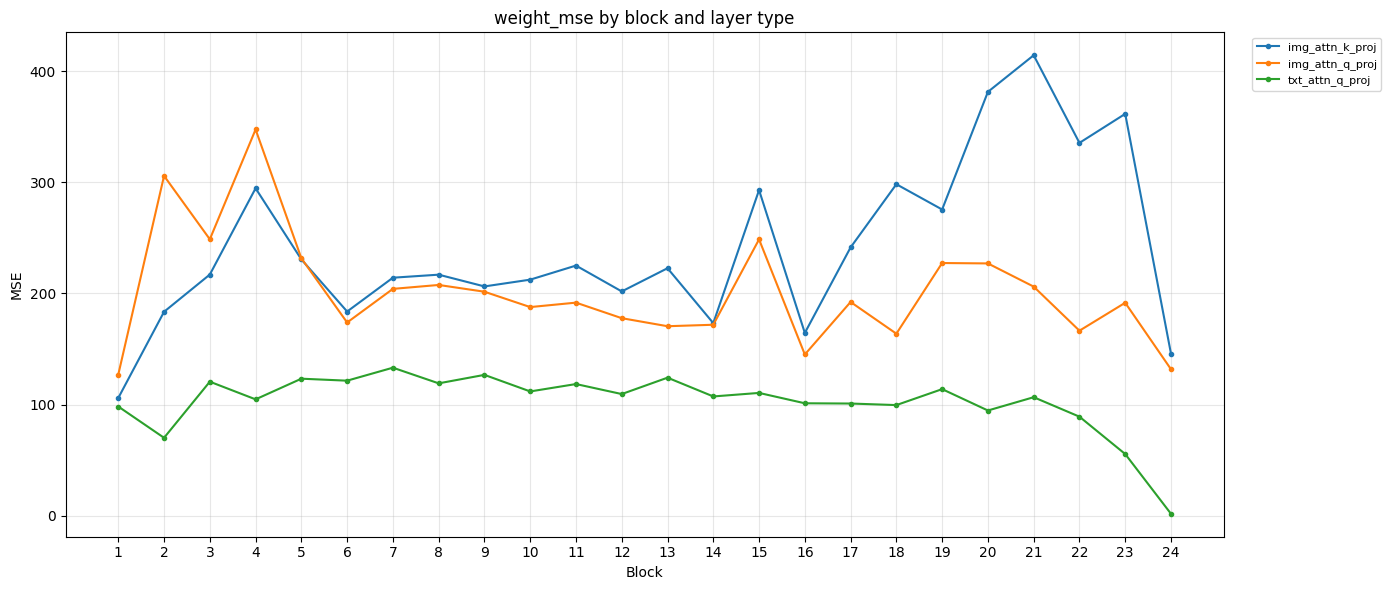

In [21]:
plot_mse_by_block(mse_key="weight_mse", layer_types=["img_attn_q_proj", "img_attn_k_proj",      
  "txt_attn_q_proj"])
# plot_mse_by_block(mse_key="activation_mse")

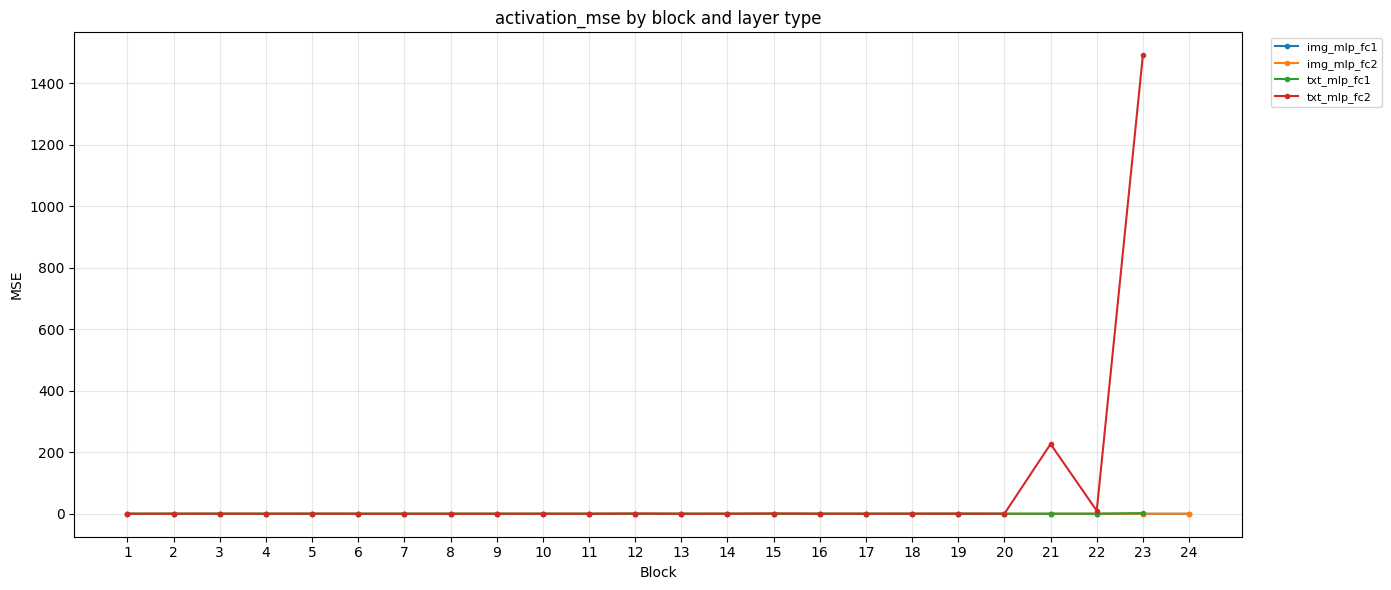

In [25]:
plot_mse_by_block(mse_key="activation_mse", layer_types=["img_mlp_fc1", "img_mlp_fc2",
  "txt_mlp_fc1", "txt_mlp_fc2"])

In [24]:
  import json
  with open('gptq_output/config.json') as f:
      c = json.load(f)

  print('=== Alpha Scales ===')
  for k, v in sorted(c['alpha_scales'].items()):
      print(f'  {k}: {v:.2f}')

=== Alpha Scales ===
  mm0_img_attn_k_proj: 0.50
  mm0_img_attn_o_proj: 0.20
  mm0_img_attn_q_proj: 0.40
  mm0_img_attn_v_proj: 0.60
  mm0_img_mlp_fc1: 0.20
  mm0_img_mlp_fc2: 0.20
  mm0_txt_attn_k_proj: 0.50
  mm0_txt_attn_o_proj: 0.60
  mm0_txt_attn_q_proj: 0.50
  mm0_txt_attn_v_proj: 0.50
  mm0_txt_mlp_fc1: 0.30
  mm0_txt_mlp_fc2: 0.50
  mm10_img_attn_k_proj: 0.50
  mm10_img_attn_o_proj: 0.20
  mm10_img_attn_q_proj: 0.60
  mm10_img_attn_v_proj: 0.70
  mm10_img_mlp_fc1: 0.90
  mm10_img_mlp_fc2: 0.20
  mm10_txt_attn_k_proj: 0.40
  mm10_txt_attn_o_proj: 0.20
  mm10_txt_attn_q_proj: 0.40
  mm10_txt_attn_v_proj: 0.30
  mm10_txt_mlp_fc1: 0.30
  mm10_txt_mlp_fc2: 0.20
  mm11_img_attn_k_proj: 0.40
  mm11_img_attn_o_proj: 0.20
  mm11_img_attn_q_proj: 0.40
  mm11_img_attn_v_proj: 0.70
  mm11_img_mlp_fc1: 1.40
  mm11_img_mlp_fc2: 0.20
  mm11_txt_attn_k_proj: 0.40
  mm11_txt_attn_o_proj: 0.20
  mm11_txt_attn_q_proj: 0.40
  mm11_txt_attn_v_proj: 0.30
  mm11_txt_mlp_fc1: 0.20
  mm11_txt_mlp_fc2: 

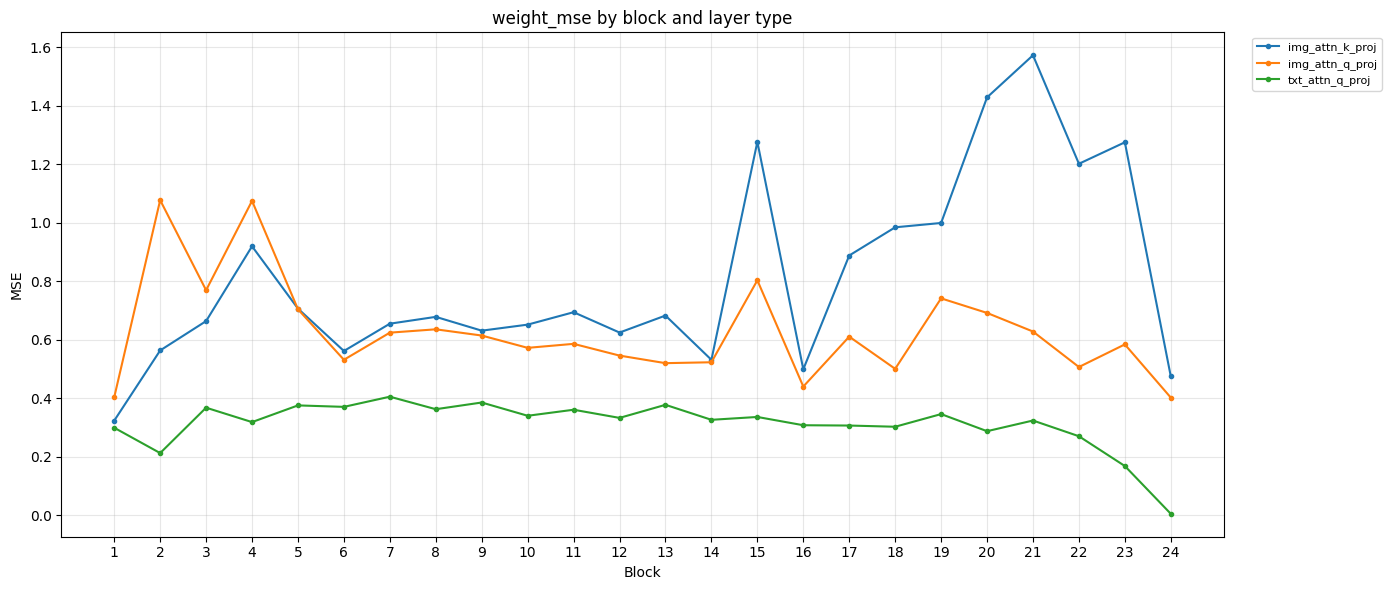

In [31]:
plot_mse_by_block(config_path="gptq_output_w8/config.json", mse_key="weight_mse", layer_types=["img_attn_q_proj", "img_attn_k_proj",      
  "txt_attn_q_proj"])

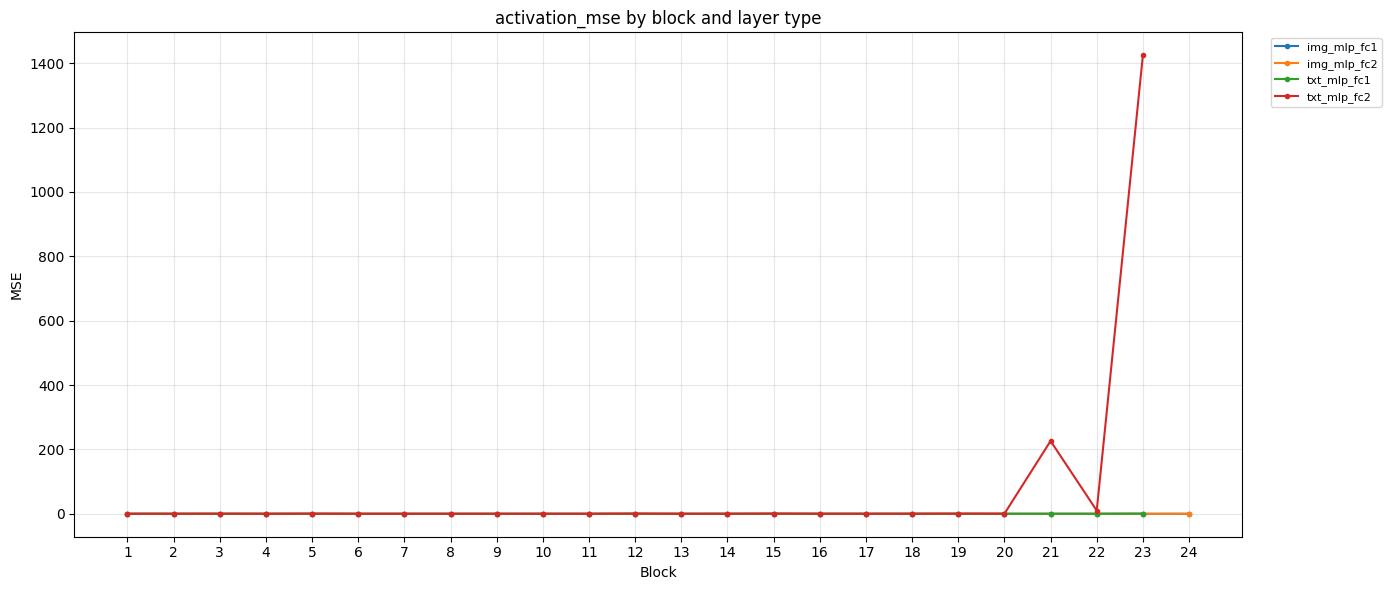

In [32]:
plot_mse_by_block(config_path="gptq_output_w8/config.json", mse_key="activation_mse", layer_types=["img_mlp_fc1", "img_mlp_fc2",
  "txt_mlp_fc1", "txt_mlp_fc2"])

# Alpha

In [26]:
def plot_alpha_by_block(config_path="gptq_output/config.json", layer_types=None, title=None):
    """Plot per-block alpha_scale as a line plot with one line per layer type.

    Args:
        config_path: Path to GPTQ config.json.
        layer_types: List of layer types to plot, e.g. ["img_attn_q_proj", "txt_mlp_fc1"].
                     If None, plots all layer types.
        title: Plot title override.
    """
    with open(config_path) as f:
        config = json.load(f)

    alpha_data = config["alpha_scales"]

    pattern = re.compile(r"^mm(\d+)_(.+)$")
    by_type = {}
    for key, alpha in alpha_data.items():
        m = pattern.match(key)
        if not m:
            continue
        block_idx = int(m.group(1))
        layer_type = m.group(2)
        if layer_types is not None and layer_type not in layer_types:
            continue
        by_type.setdefault(layer_type, {})[block_idx] = alpha

    fig, ax = plt.subplots(figsize=(14, 6))

    for layer_type in sorted(by_type.keys()):
        block_alphas = by_type[layer_type]
        blocks = sorted(block_alphas.keys())
        values = [block_alphas[b] for b in blocks]
        ax.plot([b + 1 for b in blocks], values, marker="o", markersize=3,
                label=layer_type, linewidth=1.5)

    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="baseline (1.0)")
    ax.set_xlabel("Block")
    ax.set_ylabel("Alpha Scale")
    ax.set_xticks(range(1, 25))
    ax.set_title(title or "alpha_scale by block and layer type")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

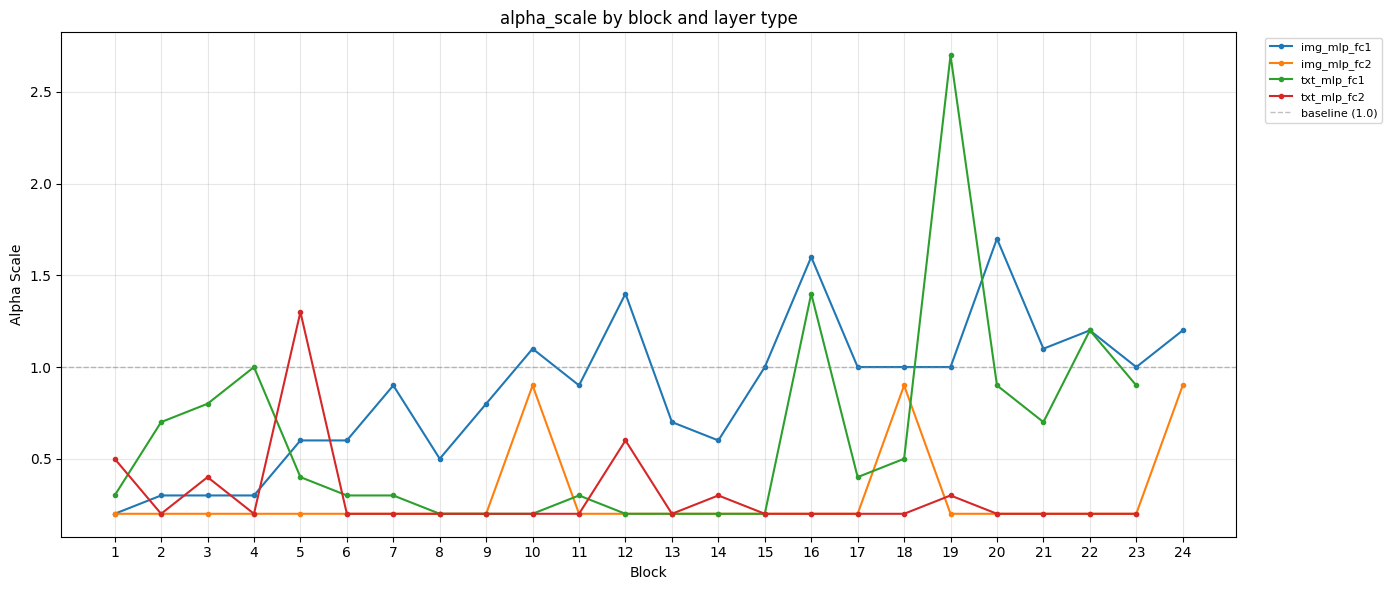

In [28]:
plot_alpha_by_block(layer_types=["img_mlp_fc1", "img_mlp_fc2",
  "txt_mlp_fc1", "txt_mlp_fc2"])